In [51]:
# Read first line function
def read_first_line(filename):
    # read the input file
    with open(filename, "r") as file:
        return file.readline().strip().split()

def read_ith_line(i, filename):
    with open(filename, "r") as file:
        for line_number, line in enumerate(file, start=1):
            if (line_number == i):
                return [float(x) for x in line.strip().split()]
            
    raise ValueError(f"File {filename} has fewer than {i} lines")

In [ ]:
# take in the list of the reciever positions and the location of the food
def newFitness(receiver, food):
    trans_duration = 150
    duration = 300

    scoringTime = 0.0
    totalScore = 0.0
    time =0

    previous_distance 
    distance = []
    
    for step in receiver:

        distance_food_receiver = abs(step - food)
        print(distance_food_receiver)
        
        if (time > trans_duration):
            if (distance_food_receiver < 5):
                distance_food_receiver = 0
            totalScore += distance_food_receiver
            scoringTime += 1
        distance.append(distance_food_receiver)
        time +=1
    
    # end of the trial
    fitness = 1 - (totalScore/scoringTime)/50
    if (fitness < 0.0):
        fitness = 0

    print("total fitness is: ",fitness)
    return distance, fitness
        


In [53]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# load in the results
result_dir = "/Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/"

date = "2026-02-23/"
# slurm_job = 15651934
slurm_job = 15811017
batch = 19
run = 0
stage = "stage1"
result_dir = result_dir + date + str(slurm_job) + "/"
overall_evolution_dir_reciever = result_dir + f"batch_{batch}/run_{run}/behavior_Receiver_{stage}_{run}.dat"


17.2808
17.28373276
17.28683007
17.29008699
17.2934969
17.2970513
17.300739999999998
17.3045509
17.30847
17.3124812
17.3165664
17.3207055
17.3248762
17.329054199999998
17.3332127
17.337322999999998
17.341354
17.3452722
17.349042
17.3526251
17.3559811
17.3590671
17.3618375
17.364244499999998
17.3662377
17.367764299999997
17.368768799999998
17.3691936
17.3689785
17.3680614
17.3663778
17.363861699999998
17.3604453
17.356059899999998
17.350635999999998
17.3441042
17.3363957
17.3274434
17.317183
17.3055541
17.292501899999998
17.27797875
17.261946
17.244376
17.2252542
17.2045812
17.182374799999998
17.158671
17.133527
17.10702
17.079247
17.050325
17.02039
16.989592
16.95809
16.926053
16.89365
16.861048
16.828407
16.795877
16.763592
16.731671
16.700217
16.669311999999998
16.639025
16.609405
16.580488
16.552296
16.524839
16.49812
16.47213
16.446856999999998
16.422282
16.398383
16.375135
16.352511
16.330485
16.309027
16.288109
16.267699999999998
16.24778
16.22832
16.20929
16.19067
16.17243999999

/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_88712/886814934.py:67: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


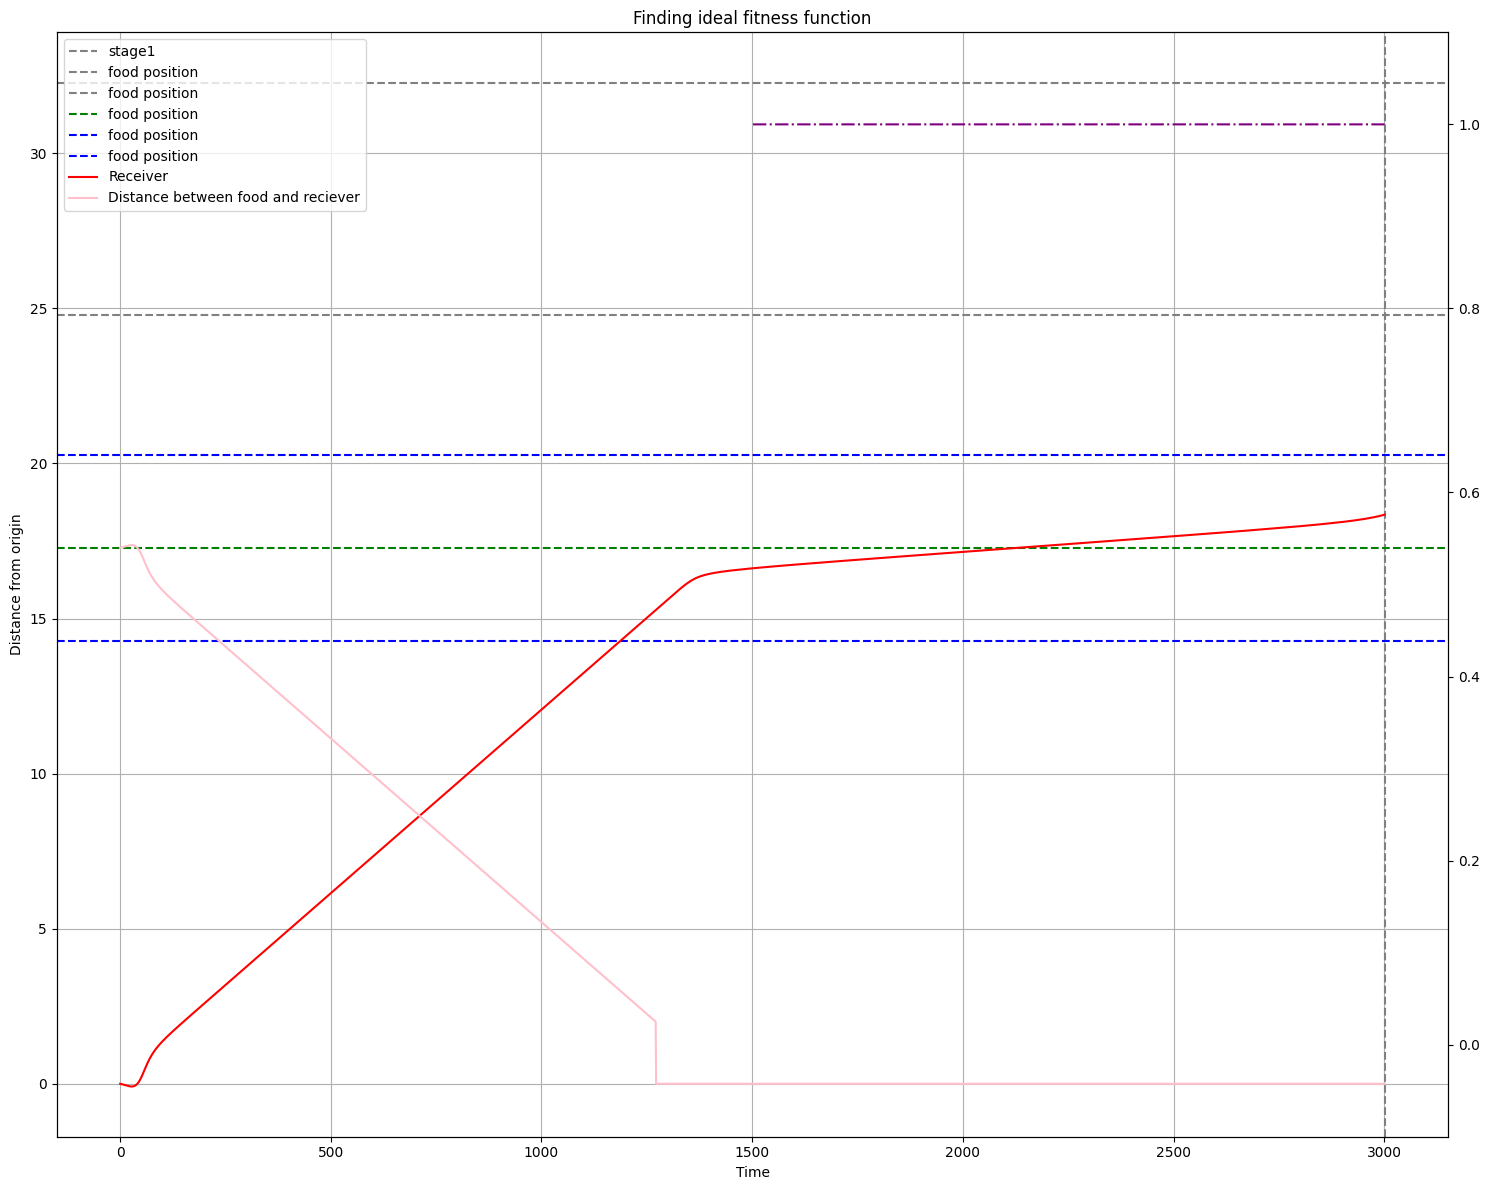

In [54]:
# this is looking at a single file

fig, axes = plt.subplots(1, 1, figsize=(15,12), sharey=True)

ax2 = axes.twinx()
ax2.set_ylim(bottom=-0.1,top=1.1)
        
combined_signaller = []
combined_receiver = []

overall_evolution_dir_reciever = result_dir + f"batch_{batch}/run_{run}/behavior_Receiver_{stage}_{run}.dat"

receiver = read_ith_line(1, overall_evolution_dir_reciever)
axes.axvline(x=len(receiver), linestyle="--", label=f"{stage}", color="grey")

combined_receiver.extend(receiver)

landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_stage1_{run}.dat"
landmark = read_ith_line(1, landmark_file)

offset = 0
fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{stage}_{run}.dat"
fitness = read_ith_line(1, fitness_file)
stage_length = len(receiver)
fitness_length = len(fitness)
fitness_start = offset + (stage_length - fitness_length)
fitness_end = offset + stage_length
fitness_x = range(fitness_start, fitness_end)

ax2.plot(fitness_x, fitness, linestyle="dashdot", color="purple")
# plot the line marking the landmark position

food = landmark[3]

landmarks = [0,1,2]
for i in landmarks:
    if (landmark[i] != food):
        axes.axhline(y=landmark[i], linestyle="--", label="food position", color="grey")


axes.axhline(y=food, linestyle="--", label="food position", color="green")
axes.axhline(y=food+3, linestyle="--", label="food position", color="blue")
axes.axhline(y=food-3, linestyle="--", label="food position", color="blue")


x = list(range(0, len(combined_receiver)))


axes.plot(x, combined_receiver, label=f"Receiver", color="red")



# new fitness
distance, _ = newFitness(combined_receiver, food)

axes.plot(x, distance, label=f"Distance between food and reciever", color="pink")

axes.set_xlabel("Time")
axes.set_ylabel("Distance from origin")

axes.set_title(f"Finding ideal fitness function")
axes.grid(True)
axes.legend()


fig.tight_layout()
fig.show()